In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
stk_data = pd.read_csv('post_dw_s_data.csv')

In [3]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5110 non-null   int64  
 1   id                 5110 non-null   int64  
 2   gender             5110 non-null   object 
 3   age                5110 non-null   float64
 4   hypertension       5110 non-null   int64  
 5   heart_disease      5110 non-null   int64  
 6   ever_married       5110 non-null   object 
 7   work_type          5110 non-null   object 
 8   Residence_type     5110 non-null   object 
 9   avg_glucose_level  5110 non-null   float64
 10  bmi                4909 non-null   float64
 11  smoking_status     5110 non-null   object 
 12  stroke             5110 non-null   int64  
 13  bmi_missing        5110 non-null   int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 559.0+ KB


In [4]:
stk_data.head()

,Unnamed: 0,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0
1,1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,1
2,2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0
3,3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0
4,4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0


In [5]:
X = stk_data.drop(columns=["Unnamed: 0", "id", "stroke", "bmi_missing"])
y = stk_data["stroke"]

print(X.shape)
print(y.shape)

(5110, 10)
(5110,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [7]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining stroke percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest stroke percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training shape: (4088, 10)
Test shape: (1022, 10)

Training stroke percentage:
stroke
0    95.132094
1     4.867906
Name: proportion, dtype: float64

Test stroke percentage:
stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


In [8]:
numeric_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [10]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [12]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", dummy_model)
])

In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
])

class_weight="balanced" used because of severe class imbalance. Instead of treating the approximately 95% non-stroke and 5% stroke observations equally, sklearn automatically gives the minority stroke class more weight.

In [14]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", decision_tree_model)
])

In [15]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", random_forest_model)
])

In [16]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [18]:
from sklearn.model_selection import cross_validate

dummy_cv = cross_validate(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Dummy Classifier")
print("Accuracy:", dummy_cv["test_accuracy"].mean())
print("Precision:", dummy_cv["test_precision"].mean())
print("Recall:", dummy_cv["test_recall"].mean())
print("F1:", dummy_cv["test_f1"].mean())
print("ROC-AUC:", dummy_cv["test_roc_auc"].mean())
print("PR-AUC:", dummy_cv["test_pr_auc"].mean())

Dummy Classifier
Accuracy: 0.9513211014116288
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5
PR-AUC: 0.0486788985883712


In [19]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression")
print("Accuracy:", logistic_cv["test_accuracy"].mean())
print("Precision:", logistic_cv["test_precision"].mean())
print("Recall:", logistic_cv["test_recall"].mean())
print("F1:", logistic_cv["test_f1"].mean())
print("ROC-AUC:", logistic_cv["test_roc_auc"].mean())
print("PR-AUC:", logistic_cv["test_pr_auc"].mean())

Logistic Regression
Accuracy: 0.7387502132256781
Precision: 0.1328638789647692
Recall: 0.788974358974359
F1: 0.22740013726307273
ROC-AUC: 0.8387359188901605
PR-AUC: 0.19327862081657324


In [20]:
decision_tree_cv = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree")
print("Accuracy:", decision_tree_cv["test_accuracy"].mean())
print("Precision:", decision_tree_cv["test_precision"].mean())
print("Recall:", decision_tree_cv["test_recall"].mean())
print("F1:", decision_tree_cv["test_f1"].mean())
print("ROC-AUC:", decision_tree_cv["test_roc_auc"].mean())
print("PR-AUC:", decision_tree_cv["test_pr_auc"].mean())

Decision Tree
Accuracy: 0.9190281098778105
Precision: 0.1506558292151307
Recall: 0.14076923076923076
F1: 0.14458016740478635
ROC-AUC: 0.5498140999554881
PR-AUC: 0.06408022161418919


In [21]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest")
print("Accuracy:", random_forest_cv["test_accuracy"].mean())
print("Precision:", random_forest_cv["test_precision"].mean())
print("Recall:", random_forest_cv["test_recall"].mean())
print("F1:", random_forest_cv["test_f1"].mean())
print("ROC-AUC:", random_forest_cv["test_roc_auc"].mean())
print("PR-AUC:", random_forest_cv["test_pr_auc"].mean())

Random Forest
Accuracy: 0.9510766026341226
Precision: 0.1
Recall: 0.005
F1: 0.009523809523809523
ROC-AUC: 0.8105711799895603
PR-AUC: 0.16288698581959002


In [22]:
results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dummy_cv["test_accuracy"].mean(),
        logistic_cv["test_accuracy"].mean(),
        decision_tree_cv["test_accuracy"].mean(),
        random_forest_cv["test_accuracy"].mean()
    ],

    "Precision": [
        dummy_cv["test_precision"].mean(),
        logistic_cv["test_precision"].mean(),
        decision_tree_cv["test_precision"].mean(),
        random_forest_cv["test_precision"].mean()
    ],

    "Recall": [
        dummy_cv["test_recall"].mean(),
        logistic_cv["test_recall"].mean(),
        decision_tree_cv["test_recall"].mean(),
        random_forest_cv["test_recall"].mean()
    ],

    "F1": [
        dummy_cv["test_f1"].mean(),
        logistic_cv["test_f1"].mean(),
        decision_tree_cv["test_f1"].mean(),
        random_forest_cv["test_f1"].mean()
    ],

    "ROC_AUC": [
        dummy_cv["test_roc_auc"].mean(),
        logistic_cv["test_roc_auc"].mean(),
        decision_tree_cv["test_roc_auc"].mean(),
        random_forest_cv["test_roc_auc"].mean()
    ],

    "PR_AUC": [
        dummy_cv["test_pr_auc"].mean(),
        logistic_cv["test_pr_auc"].mean(),
        decision_tree_cv["test_pr_auc"].mean(),
        random_forest_cv["test_pr_auc"].mean()
    ]
})

results.sort_values(by="PR_AUC", ascending=False).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Logistic Regression,0.739,0.133,0.789,0.227,0.839,0.193
3,Random Forest,0.951,0.100,0.005,0.010,0.811,0.163
2,Decision Tree,0.919,0.151,0.141,0.145,0.550,0.064
0,Dummy,0.951,0.000,0.000,0.000,0.500,0.049


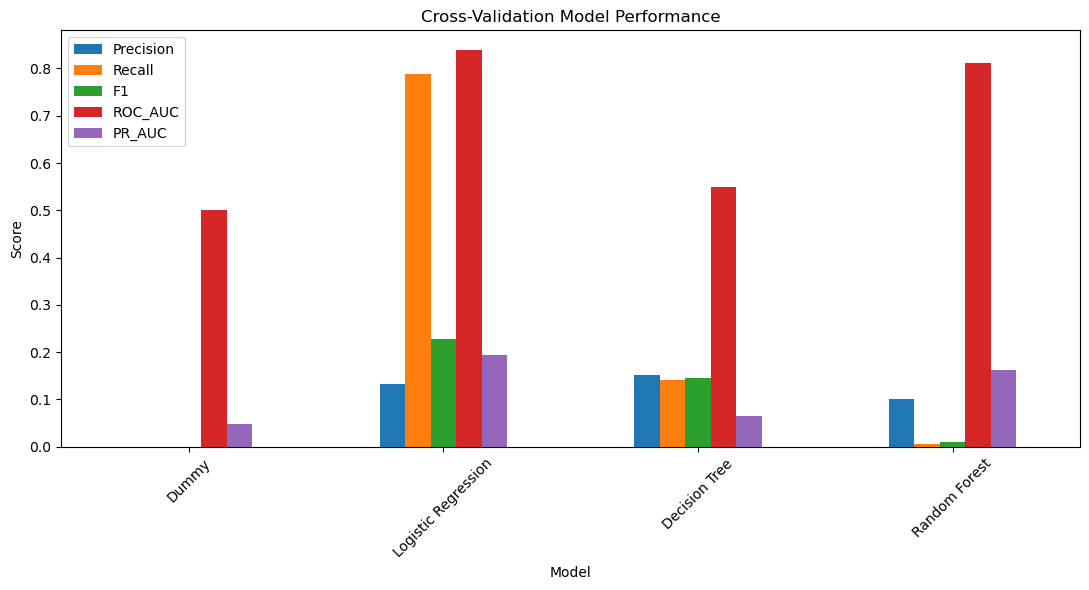

In [23]:
results_plot = results.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Cross-Validation Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

In [25]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequen...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status']),
                                                                        ('bin',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='average_precision')

In [26]:
print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest CV PR-AUC:")
print(logistic_grid.best_score_)

Best parameters:
{'classifier__C': 1}

Best CV PR-AUC:
0.19327862081657324


In [27]:
logistic_tuning_results = pd.DataFrame(
    logistic_grid.cv_results_
)

logistic_tuning_results[
    [
        "param_classifier__C",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_classifier__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,1.00,0.185825,0.193279,0.038894,1
4,100.00,0.185436,0.193103,0.039163,2
3,10.00,0.185446,0.193025,0.039150,3
1,0.10,0.185164,0.192776,0.037986,4
0,0.01,0.181733,0.188181,0.033646,5


In [28]:
best_logistic = logistic_grid.best_estimator_

In [29]:
best_logistic

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('bin', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [30]:
best_C = logistic_grid.best_params_["classifier__C"]

tuned_logistic_model = LogisticRegression(
    C=best_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

tuned_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", tuned_logistic_model)
])

In [31]:
tuned_logistic_cv = cross_validate(
    tuned_logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Logistic Regression")
print("Accuracy:", tuned_logistic_cv["test_accuracy"].mean())
print("Precision:", tuned_logistic_cv["test_precision"].mean())
print("Recall:", tuned_logistic_cv["test_recall"].mean())
print("F1:", tuned_logistic_cv["test_f1"].mean())
print("ROC-AUC:", tuned_logistic_cv["test_roc_auc"].mean())
print("PR-AUC:", tuned_logistic_cv["test_pr_auc"].mean())

Tuned Logistic Regression
Accuracy: 0.7387502132256781
Precision: 0.1328638789647692
Recall: 0.788974358974359
F1: 0.22740013726307273
ROC-AUC: 0.8387359188901605
PR-AUC: 0.19327862081657324


Logistic Regression  
Accuracy: 0.7387502132256781  
Precision: 0.1328638789647692  
Recall: 0.788974358974359  
F1: 0.22740013726307273  
ROC-AUC: 0.8387359188901605  
PR-AUC: 0.19327862081657324

In [32]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5]
}

In [33]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

random_forest_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequen...
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10],
                         'classifier__min_samples_leaf': [1, 2, 5],
                         'classifier__n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='average_precision')

In [34]:
print("Best parameters:")
print(random_forest_grid.best_params_)

print("\nBest CV PR-AUC:")
print(random_forest_grid.best_score_)

Best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Best CV PR-AUC:
0.1801428253524229


In [35]:
rf_tuning_results = pd.DataFrame(
    random_forest_grid.cv_results_
)

rf_tuning_results[
    [
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
9,100,5,1,0.388124,0.180143,0.042400,1
8,300,None,5,0.891666,0.179135,0.030033,2
7,200,None,5,0.892421,0.178728,0.030290,3
13,200,5,2,0.396673,0.178306,0.041160,4
12,100,5,2,0.384018,0.178189,0.038785,5
10,200,5,1,0.396330,0.178003,0.040035,6
14,300,5,2,0.399681,0.176226,0.039656,7
11,300,5,1,0.400117,0.176026,0.037850,8
15,100,5,5,0.374362,0.175768,0.035361,9
16,200,5,5,0.382906,0.173941,0.035043,10


In [36]:
best_random_forest = random_forest_grid.best_estimator_

In [37]:
tuned_random_forest_cv = cross_validate(
    best_random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Random Forest")
print("Accuracy:", tuned_random_forest_cv["test_accuracy"].mean())
print("Precision:", tuned_random_forest_cv["test_precision"].mean())
print("Recall:", tuned_random_forest_cv["test_recall"].mean())
print("F1:", tuned_random_forest_cv["test_f1"].mean())
print("ROC-AUC:", tuned_random_forest_cv["test_roc_auc"].mean())
print("PR-AUC:", tuned_random_forest_cv["test_pr_auc"].mean())

Tuned Random Forest
Accuracy: 0.7147743698246012
Precision: 0.120324043119212
Recall: 0.7688461538461538
F1: 0.20802236540445418
ROC-AUC: 0.8238755427508642
PR-AUC: 0.1801428253524229


In [38]:
dt_param_grid = {
    "classifier__max_depth": [3, 5, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 5, 10]
}

In [39]:
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=dt_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

decision_tree_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequen...
                                                                          'smoking_status']),
                                                                        ('bin',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [3, 5, 10, None],
                         'classifier__min_samples_leaf': [1, 5, 10],
                         'classifier__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='average_precision')

In [40]:
print("Best parameters:")
print(decision_tree_grid.best_params_)

print("\nBest CV PR-AUC:")
print(decision_tree_grid.best_score_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}

Best CV PR-AUC:
0.14914757543111162


In [41]:
best_decision_tree = decision_tree_grid.best_estimator_

tuned_decision_tree_cv = cross_validate(
    best_decision_tree,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Decision Tree")
print("Accuracy:", tuned_decision_tree_cv["test_accuracy"].mean())
print("Precision:", tuned_decision_tree_cv["test_precision"].mean())
print("Recall:", tuned_decision_tree_cv["test_recall"].mean())
print("F1:", tuned_decision_tree_cv["test_f1"].mean())
print("ROC-AUC:", tuned_decision_tree_cv["test_roc_auc"].mean())
print("PR-AUC:", tuned_decision_tree_cv["test_pr_auc"].mean())

Tuned Decision Tree
Accuracy: 0.7800821779244836
Precision: 0.1317938227931148
Recall: 0.6278205128205128
F1: 0.2176936252758291
ROC-AUC: 0.7164610696744373
PR-AUC: 0.14914757543111162


In [42]:
y_pred = best_logistic.predict(X_test)

y_prob = best_logistic.predict_proba(X_test)[:, 1]

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_pr_auc = average_precision_score(y_test, y_prob)

print("Final Logistic Regression Test Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)
print("ROC-AUC:", test_roc_auc)
print("PR-AUC:", test_pr_auc)

Final Logistic Regression Test Results
Accuracy: 0.7455968688845401
Precision: 0.13793103448275862
Recall: 0.8
F1: 0.23529411764705882
ROC-AUC: 0.8436831275720165
PR-AUC: 0.2681951065248516


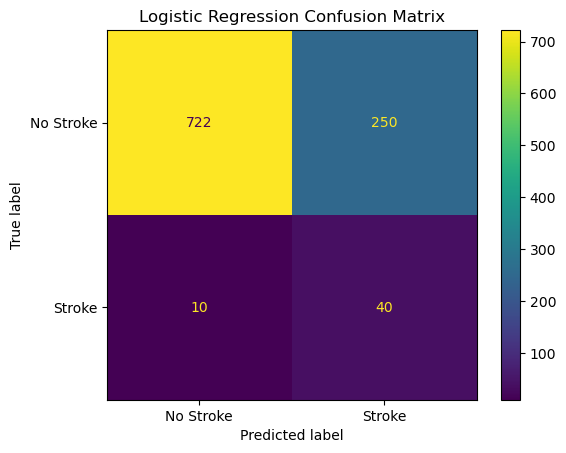

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Stroke", "Stroke"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

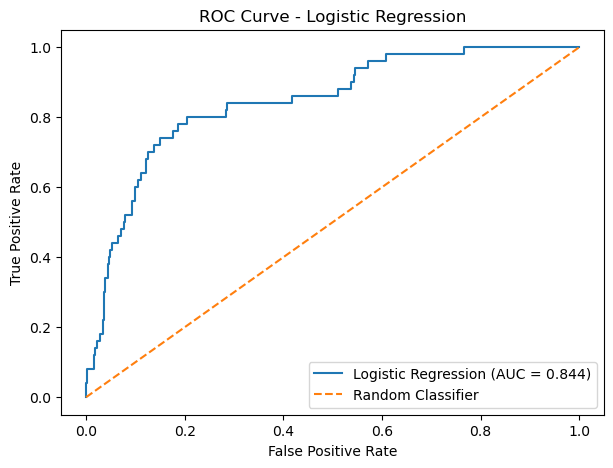

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

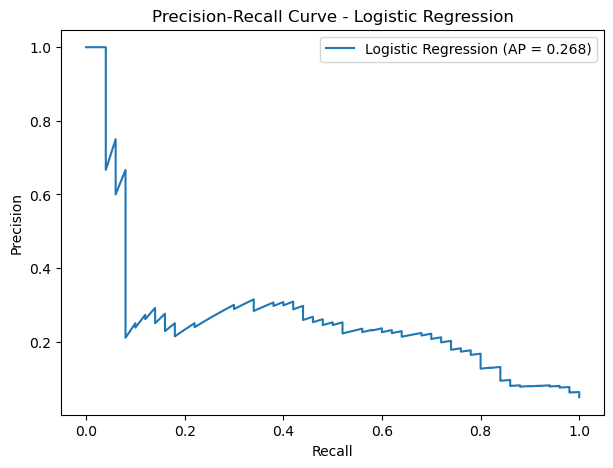

In [46]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

In [47]:
fitted_preprocessor = best_logistic.named_steps["preprocessor"]
fitted_logistic = best_logistic.named_steps["classifier"]

In [48]:
feature_names = fitted_preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__avg_glucose_level' 'num__bmi' 'cat__gender_Female'
 'cat__gender_Male' 'cat__gender_Other' 'cat__ever_married_No'
 'cat__ever_married_Yes' 'cat__work_type_Govt_job'
 'cat__work_type_Never_worked' 'cat__work_type_Private'
 'cat__work_type_Self-employed' 'cat__work_type_children'
 'cat__Residence_type_Rural' 'cat__Residence_type_Urban'
 'cat__smoking_status_Unknown' 'cat__smoking_status_formerly smoked'
 'cat__smoking_status_never smoked' 'cat__smoking_status_smokes'
 'bin__hypertension' 'bin__heart_disease']


In [50]:
coefficients = fitted_logistic.coef_[0]

In [51]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df

,Feature,Coefficient
0,num__age,1.882379
1,num__avg_glucose_level,0.200228
2,num__bmi,0.050067
3,cat__gender_Female,-0.098734
4,cat__gender_Male,-0.228791
5,cat__gender_Other,-0.010305
6,cat__ever_married_No,-0.086793
7,cat__ever_married_Yes,-0.251037
8,cat__work_type_Govt_job,-0.257647
9,cat__work_type_Never_worked,-0.047033


In [52]:
coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,num__age,1.882379
12,cat__work_type_children,0.678058
19,bin__hypertension,0.589278
20,bin__heart_disease,0.223842
1,num__avg_glucose_level,0.200228
18,cat__smoking_status_smokes,0.168379
2,num__bmi,0.050067
5,cat__gender_Other,-0.010305
16,cat__smoking_status_formerly smoked,-0.012441
9,cat__work_type_Never_worked,-0.047033


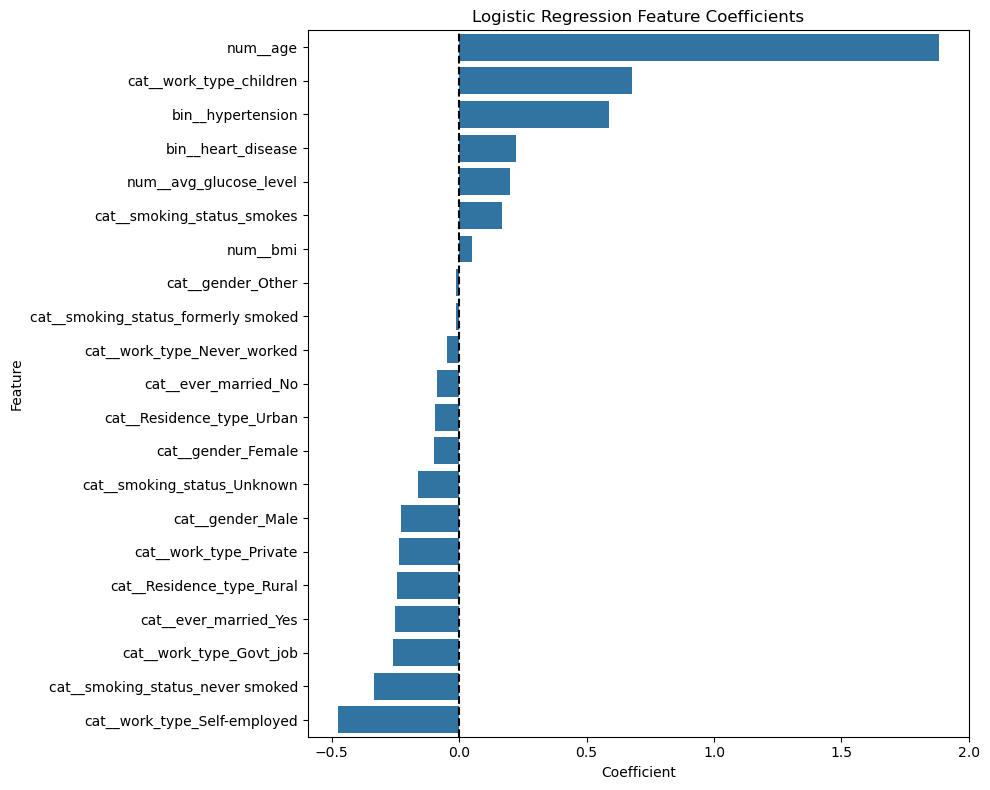

In [53]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()